# Digit Recognition
Pipeline: **CNN ensemble + TTA**

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
print("ok")

In [ ]:
DATA_DIR = 'data'
IMG_SIZE = (28, 28)

def find_train_image(img_id, category):
    path = os.path.join(DATA_DIR, 'train', 'train', str(category), f'{img_id}.png')
    if os.path.exists(path):
        return path
    for cat in range(10):
        p = os.path.join(DATA_DIR, 'train', 'train', str(cat), f'{img_id}.png')
        if os.path.exists(p):
            print(f'WARNING: image {img_id} found in class {cat}, expected class {category}')
            return p
    return None

def find_test_image(img_id):
    for candidate in [
        os.path.join(DATA_DIR, 'test', f'{img_id}.png'),
        *[os.path.join(DATA_DIR, 'test', 'test', str(c), f'{img_id}.png') for c in range(10)],
        os.path.join(DATA_DIR, 'test', 'test', f'{img_id}.png'),
    ]:
        if os.path.exists(candidate):
            return candidate
    return None

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'cv2.imread failed to load image: {path}')
    return cv2.resize(img, IMG_SIZE)

## Load Training Data

In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

X_train_raw, y_train = [], []
missing = 0

for _, row in train_df.iterrows():
    path = find_train_image(row['Id'], row['Category'])
    if path is None:
        missing += 1
        continue
    X_train_raw.append(load_image(path))
    y_train.append(int(row['Category']))

X_train_raw = np.array(X_train_raw, dtype=np.uint8)
y_train     = np.array(y_train)
print(f'{len(X_train_raw)} samples  raw: {X_train_raw.shape[1:]}  {missing} missing')

## Train/Val Split

In [ ]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(y_train))
idx_tr, idx_val = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y_train
)
X_tr_raw, X_val_raw = X_train_raw[idx_tr], X_train_raw[idx_val]
y_tr,     y_val     = y_train[idx_tr],     y_train[idx_val]

## Train Ensemble (held-out validation)

Device: cuda  |  members: 7  |  epochs/member: 30
[1/7] Training (seed=42)
  seed=42  epoch  5/30  val(2-TTA): 99.59%
  seed=42  epoch 10/30  val(2-TTA): 99.79%
  seed=42  epoch 15/30  val(2-TTA): 99.79%
  seed=42  epoch 20/30  val(2-TTA): 99.88%
  seed=42  epoch 25/30  val(2-TTA): 99.91%
  seed=42  epoch 30/30  val(2-TTA): 99.79%
    saved -> sota_ensemble\member_0.pt
[2/7] Training (seed=43)
  seed=43  epoch  5/30  val(2-TTA): 99.50%
  seed=43  epoch 10/30  val(2-TTA): 99.74%
  seed=43  epoch 15/30  val(2-TTA): 99.74%
  seed=43  epoch 20/30  val(2-TTA): 99.79%
  seed=43  epoch 25/30  val(2-TTA): 99.82%
  seed=43  epoch 30/30  val(2-TTA): 99.91%
    saved -> sota_ensemble\member_1.pt
[3/7] Training (seed=44)
  seed=44  epoch  5/30  val(2-TTA): 99.09%
  seed=44  epoch 10/30  val(2-TTA): 99.47%
  seed=44  epoch 15/30  val(2-TTA): 99.82%
  seed=44  epoch 20/30  val(2-TTA): 99.82%
  seed=44  epoch 25/30  val(2-TTA): 99.82%
  seed=44  epoch 30/30  val(2-TTA): 99.85%
    saved -> sota_ensem

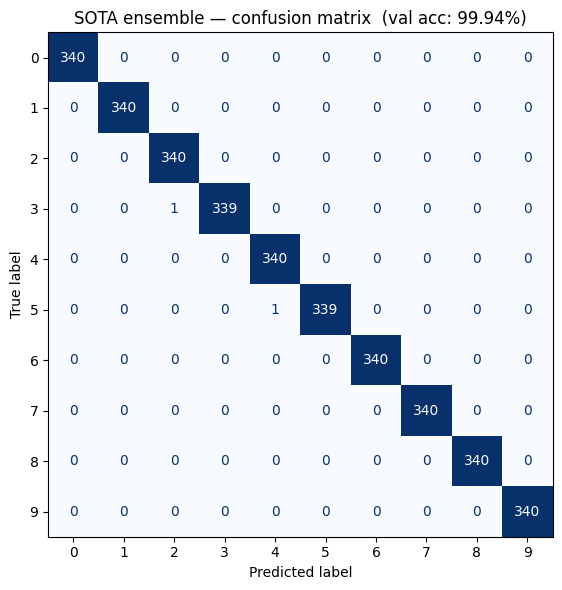

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       340
           1     1.0000    1.0000    1.0000       340
           2     0.9971    1.0000    0.9985       340
           3     1.0000    0.9971    0.9985       340
           4     0.9971    1.0000    0.9985       340
           5     1.0000    0.9971    0.9985       340
           6     1.0000    1.0000    1.0000       340
           7     1.0000    1.0000    1.0000       340
           8     1.0000    1.0000    1.0000       340
           9     1.0000    1.0000    1.0000       340

    accuracy                         0.9994      3400
   macro avg     0.9994    0.9994    0.9994      3400
weighted avg     0.9994    0.9994    0.9994      3400


Misclassified: 2 / 3400  (0.06%)


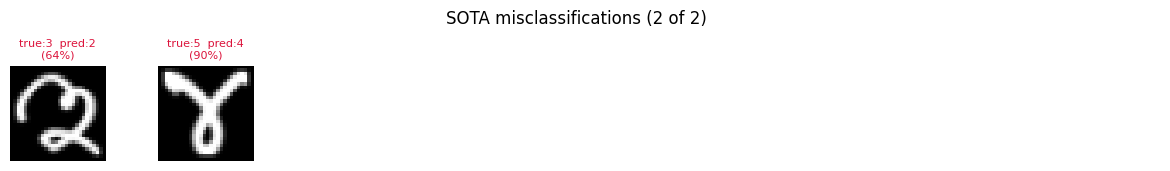

In [ ]:
import math
import random
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T



SOTA_DIR     = 'sota_ensemble'
N_MEMBERS    = 7
EPOCHS       = 30
BATCH_SIZE   = 128
BASE_LR      = 1e-3
WEIGHT_DECAY = 5e-4
LABEL_SMOOTH = 0.1
MIXUP_ALPHA  = 0.2
TTA_PASSES   = 8
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs(SOTA_DIR, exist_ok=True)


class WideCNN(nn.Module):
    def __init__(self, n_classes=10, p_drop=0.4):
        super().__init__()
        def conv_bn(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )
        self.b1 = conv_bn(1, 64)
        self.b2 = conv_bn(64, 128)
        self.b3 = conv_bn(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(p_drop),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.pool(self.b1(x))
        x = self.pool(self.b2(x))
        x = self.b3(x) 
        x = self.gap(x).flatten(1)
        return self.head(x)


class _Cutout:
    def __init__(self, size=8, p=0.5):
        self.size, self.p = size, p
    def __call__(self, img_tensor):
        if random.random() > self.p:
            return img_tensor
        _, h, w = img_tensor.shape
        cy, cx = random.randint(0, h - 1), random.randint(0, w - 1)
        y0, y1 = max(0, cy - self.size // 2), min(h, cy + self.size // 2)
        x0, x1 = max(0, cx - self.size // 2), min(w, cx + self.size // 2)
        img_tensor[:, y0:y1, x0:x1] = 0.0
        return img_tensor


class SOTADataset(Dataset):
    def __init__(self, X, y, augment):
        self.X, self.y = X, y
        if augment:
            self.tf = T.Compose([
                T.ToPILImage(),
                T.RandomAffine(degrees=15, translate=(0.12, 0.12),
                               scale=(0.85, 1.15), shear=10, fill=0),
                T.ToTensor(),
                _Cutout(size=8, p=0.5),
            ])
        else:
            self.tf = T.Compose([T.ToPILImage(), T.ToTensor()])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.tf(self.X[i]), int(self.y[i])


def _seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _warmup_cosine(step, total, warmup):
    if step < warmup:
        return step / max(1, warmup)
    progress = (step - warmup) / max(1, total - warmup)
    return 0.5 * (1.0 + math.cos(math.pi * progress))


def _mixup(x, y, alpha):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def train_member(X, y, X_val=None, y_val=None, *, seed, epochs=EPOCHS):
    _seed_all(seed)
    model = WideCNN().to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
    crit  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
    loader = DataLoader(SOTADataset(X, y, augment=True),
                        batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, pin_memory=(DEVICE == 'cuda'))
    total_steps = epochs * len(loader)
    warmup_steps = max(1, int(0.05 * total_steps))
    step = 0
    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            xb_m, ya, yb_, lam = _mixup(xb, yb, MIXUP_ALPHA)
            logits = model(xb_m)
            loss = lam * crit(logits, ya) + (1 - lam) * crit(logits, yb_)
            opt.zero_grad()
            loss.backward()
            scale = _warmup_cosine(step, total_steps, warmup_steps)
            for g in opt.param_groups:
                g['lr'] = BASE_LR * scale
            opt.step()
            step += 1
        if X_val is not None and ((ep + 1) % 5 == 0 or ep == epochs - 1):
            v = (predict_tta(model, X_val, n=2).argmax(1) == y_val).mean()
            print(f'  seed={seed}  epoch {ep+1:2d}/{epochs}  val: {v:.2%}')
    return model


@torch.no_grad()
def predict_tta(model, X, n=TTA_PASSES, batch_size=256):
    model.eval()
    sum_probs = np.zeros((len(X), 10), dtype=np.float32)
    for pass_idx in range(n):
        ds = SOTADataset(X, np.zeros(len(X)), augment=(pass_idx > 0))
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                            num_workers=0, pin_memory=(DEVICE == 'cuda'))
        out = []
        for xb, _ in loader:
            out.append(F.softmax(model(xb.to(DEVICE)), dim=1).cpu().numpy())
        sum_probs += np.vstack(out)
    return sum_probs / n


sota_models = []
for k in range(N_MEMBERS):
    ckpt = os.path.join(SOTA_DIR, f'member_{k}.pt')
    if os.path.exists(ckpt):
        print(f'[{k+1}/{N_MEMBERS}] Loading {ckpt}')
        m = WideCNN().to(DEVICE)
        m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    else:
        print(f'{k+1}/{N_MEMBERS} Training (seed={42 + k})')
        m = train_member(X_tr_raw, y_tr, X_val_raw, y_val, seed=42 + k)
        torch.save(m.state_dict(), ckpt)
        print(f'saved - {ckpt}')
    sota_models.append(m)


print('\nEvaluating')
val_probs_per_model = [predict_tta(m, X_val_raw) for m in sota_models]
sota_val_probs = np.mean(val_probs_per_model, axis=0)
sota_val_preds = sota_val_probs.argmax(1)
sota_val_acc   = (sota_val_preds == y_val).mean()

for k, p in enumerate(val_probs_per_model):
    print(f'  member {k}: {(p.argmax(1) == y_val).mean():.2%}')
print(f'  ensemble (mean TTA-softmaxes): {sota_val_acc:.2%}')

cm = confusion_matrix(y_val, sota_val_preds)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10))).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion matrix  (val acc: {sota_val_acc:.2%})')
plt.tight_layout(); plt.show()

print(classification_report(y_val, sota_val_preds, digits=4))

wrong = np.where(sota_val_preds != y_val)[0]
print(f'\nMisclassified: {len(wrong)} / {len(y_val)}  ({len(wrong)/len(y_val):.2%})')
if len(wrong):
    n_show = min(len(wrong), 24)
    cols = 8
    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.7))
    fig.suptitle(f'SOTA misclassifications ({n_show} of {len(wrong)})', fontsize=12)
    axes = np.atleast_2d(axes).flatten()
    for ax in axes:
        ax.axis('off')
    for ax, i in zip(axes, wrong[:n_show]):
        conf = sota_val_probs[i, sota_val_preds[i]]
        ax.imshow(X_val_raw[i], cmap='gray')
        ax.set_title(f'true:{y_val[i]}  pred:{sota_val_preds[i]}\n({conf:.0%})',
                     fontsize=8, color='crimson')
    plt.tight_layout(); plt.show()

## Train on Full Data and Submit

[1/7] Training on full data (seed=142)
    saved -> sota_ensemble_full\member_0.pt
[2/7] Training on full data (seed=143)
    saved -> sota_ensemble_full\member_1.pt
[3/7] Training on full data (seed=144)
    saved -> sota_ensemble_full\member_2.pt
[4/7] Training on full data (seed=145)
    saved -> sota_ensemble_full\member_3.pt
[5/7] Training on full data (seed=146)
    saved -> sota_ensemble_full\member_4.pt
[6/7] Training on full data (seed=147)
    saved -> sota_ensemble_full\member_5.pt
[7/7] Training on full data (seed=148)
    saved -> sota_ensemble_full\member_6.pt
Loaded 3000 test images. Running ensemble + TTA...
Saved 3000 rows to submission_sota.csv
Validation accuracy of held-out ensemble: 99.94%
Mean test confidence: 88.62%  (min: 37.91%, <90% confidence: 2006)


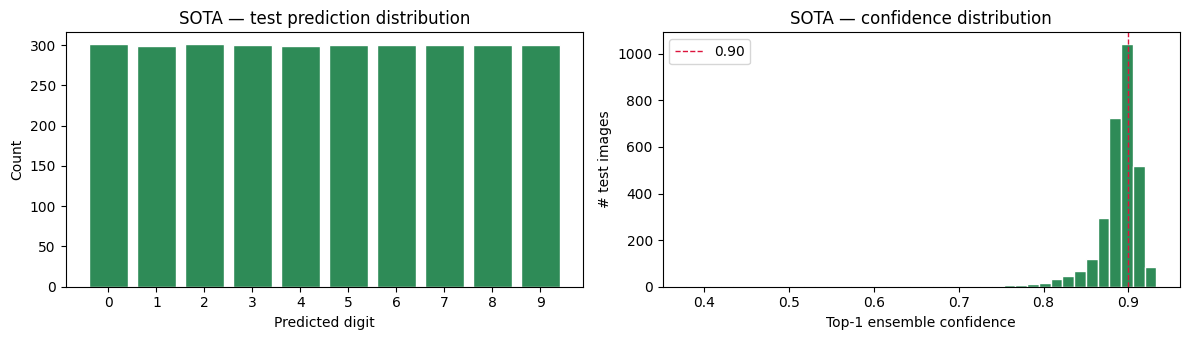

In [ ]:
SOTA_FULL_DIR = 'sota_ensemble_full'
os.makedirs(SOTA_FULL_DIR, exist_ok=True)

sota_full_models = []
for k in range(N_MEMBERS):
    ckpt = os.path.join(SOTA_FULL_DIR, f'member_{k}.pt')
    if os.path.exists(ckpt):
        print(f'{k+1}/{N_MEMBERS} Loading {ckpt}')
        m = WideCNN().to(DEVICE)
        m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    else:
        print(f'{k+1}/{N_MEMBERS} Training on full data (seed={142 + k})')
        m = train_member(X_train_raw, y_train, seed=142 + k)
        torch.save(m.state_dict(), ckpt)
        print(f'    saved -> {ckpt}')
    sota_full_models.append(m)

sota_test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sota_test_ids, sota_test_paths = [], []
for img_id in sota_test_df['Id']:
    path = find_test_image(img_id)
    if path is None:
        continue
    sota_test_ids.append(img_id)
    sota_test_paths.append(path)

sota_test_X = np.array([load_image(p) for p in sota_test_paths], dtype=np.uint8)
print(f'Running ensemble and TTA.')

sota_test_probs = np.mean([predict_tta(m, sota_test_X) for m in sota_full_models], axis=0)
sota_test_preds = sota_test_probs.argmax(1)
sota_test_conf  = sota_test_probs.max(1)

sota_submission = pd.DataFrame({'Id': sota_test_ids, 'Category': sota_test_preds})
sota_submission.to_csv('submission_sota.csv', index=False)
print(f'Validation accuracy of ensemble: {sota_val_acc:.2%}')
print(f'Mean test confidence: {sota_test_conf.mean():.2%}  '
      f'(min: {sota_test_conf.min():.2%}, '
      f'<90% confidence: {(sota_test_conf < 0.90).sum()})')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

uniq, cnts = np.unique(sota_test_preds, return_counts=True)
axes[0].bar(uniq, cnts, color='seagreen', edgecolor='white')
axes[0].set_xlabel('Predicted digit'); axes[0].set_ylabel('Count')
axes[0].set_title('SOTA — test prediction distribution')
axes[0].set_xticks(uniq)

axes[1].hist(sota_test_conf, bins=40, color='seagreen', edgecolor='white')
axes[1].set_xlabel('Top-1 ensemble confidence')
axes[1].set_ylabel('# test images')
axes[1].set_title('SOTA — confidence distribution')
axes[1].axvline(0.9, color='crimson', linestyle='--', linewidth=1, label='0.90')
axes[1].legend()

plt.tight_layout(); plt.show()